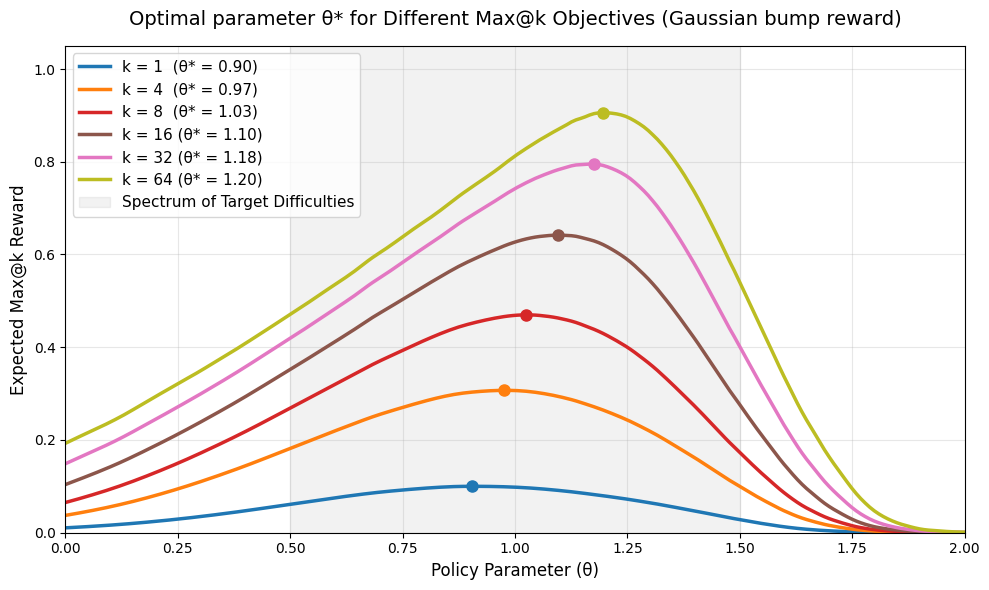

In [1]:
import os
from concurrent.futures import ProcessPoolExecutor

import scipy.special as sc
from scipy.integrate import quad_vec
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import gammaln

def leave_one_out(Y):
    """
    Y: (m, n)
    Returns: (m, n * (n - 1)) — each row of Y expanded to n rows of length n-1, then raveled.
    """
    m, n = Y.shape
    j = np.arange(n)[:, None]
    k = np.arange(n - 1)[None, :]
    col = np.where(k < j, k, k + 1)
    return Y[:, col].reshape(m * n, n - 1)


# =====================================================================
# 1. EMPIRICAL SAMPLING FOR THE CONTINUOUS SPECTRUM
# =====================================================================

SIGMA = 0.2
THETA_INIT = 0.2
# Bump width τ = TAU_SCALE * sqrt(W). Peak stays at Z = X²; TAU_SCALE < 1 => sharper (narrower) bump.
TAU_SCALE = 0.2
# Policy / networks observe X of shape (n, X_DIM); column 0 is task difficulty u ~ U(0.5,1.5),
# remaining columns are random covariates (reward depends only on u for scalar θ).
X_DIM = 16  # change here; nets use in_features=X_DIM (re-run setup + training cells after)

def sample_data(n_problems, n_generations, sigma=SIGMA, theta_init=THETA_INIT):
    if X_DIM < 1:
        raise ValueError("X_DIM must be >= 1")
    x0 = np.random.uniform(0.5, 1.5, n_problems)
    if X_DIM == 1:
        X = x0.reshape(-1, 1)
    else:
        extras = np.random.standard_normal((n_problems, X_DIM - 1))
        X = np.column_stack([x0, extras])
    W = 0.07 - 0.04 * x0
    Z = np.random.normal(loc=theta_init * x0[:, None], scale=sigma, size=(n_problems, n_generations))

    tau = (TAU_SCALE * np.sqrt(W))[:, np.newaxis]
    target = (x0**2)[:, np.newaxis]
    Y = np.exp(-((Z - target) ** 2) / (2 * tau**2))

    score = ((Z - theta_init * x0[:, None]) * x0[:, None]) / sigma**2
    return X, Z, Y, score


# def _analytical_theta_chunk(payload):
#     """Worker function for parallel exact 1D Quadrature computation."""
#     thetas_block, k_arr, sigma, n_x, tau_scale = payload
#     X = np.linspace(0.5, 1.5, n_x)
#     W = 0.07 - 0.04 * X
#     tau = tau_scale * np.sqrt(W)
#     target = X**2
    
#     expected_rewards = {k: np.zeros(len(thetas_block)) for k in k_arr}
    
#     # Pre-calculate invariant constants for the Gaussian calculations
#     inv_s_y = 1.0 / sigma
#     inv_s_y_sqrt_2pi = inv_s_y / np.sqrt(2 * np.pi)
#     sqrt_2 = np.sqrt(2.0)
    
#     for i, theta in enumerate(thetas_block):
#         mu_Y = (theta * X) - target
#         theta_k_rewards = np.zeros(len(k_arr))
        
#         for j in range(len(X)):
#             m_y, t_y = mu_Y[j], tau[j]
            
#             # 1. High-Performance Folded Normal PDF
#             def f_D(d):
#                 z1 = (d - m_y) * inv_s_y
#                 z2 = (-d - m_y) * inv_s_y
#                 return inv_s_y_sqrt_2pi * (np.exp(-0.5 * z1**2) + np.exp(-0.5 * z2**2))
            
#             # 2. High-Performance Folded Normal CDF
#             def F_D(d):
#                 z1 = (d - m_y) * inv_s_y
#                 z2 = (-d - m_y) * inv_s_y
#                 # CDF(z) = 0.5 * (1 + erf(z / sqrt(2)))
#                 return 0.5 * (sc.erf(z1 / sqrt_2) - sc.erf(z2 / sqrt_2))
            
#             # 3. Vectorized Integrand across all k
#             def integrand(m):
#                 reward = np.exp(-(m**2) / (2 * t_y**2))
#                 prob_val = np.clip(1.0 - F_D(m), 1e-12, 1.0)
                
#                 # Evaluates f_M(m) for all k simultaneously
#                 f_M = k_arr * (prob_val**(k_arr - 1)) * f_D(m)
#                 return reward * f_M
            
#             upper_bound = 5.0 * sigma + np.abs(m_y)
            
#             # quad_vec returns an array of shape (len(k_arr),)
#             res, _ = quad_vec(integrand, 0, upper_bound)
#             theta_k_rewards += res
            
#         # Average over the X problem distribution
#         theta_k_rewards /= len(X)
        
#         # Store results for this theta
#         for idx, k in enumerate(k_arr):
#             expected_rewards[k][i] = theta_k_rewards[idx]
            
#     return expected_rewards


# def compute_analytical_curves(
#     thetas,
#     k_values,
#     sigma=SIGMA,
#     tau_scale=TAU_SCALE,
#     n_x=256,
#     n_jobs=None,
# ):
#     """
#     Computes exact E[max@k] curves using 1D numerical quadrature, bypassing Monte Carlo entirely.
#     """
#     thetas = np.asarray(thetas, dtype=np.float64)
#     k_arr = np.array(k_values, dtype=np.int64)
    
#     nj = os.cpu_count() or 1 if n_jobs is None else int(n_jobs)
#     if nj < 1:
#         nj = 1

#     expected_rewards = {k: np.zeros(len(thetas)) for k in k_values}

#     # If running sequentially
#     if nj == 1:
#         payload = (thetas, k_arr, float(sigma), int(n_x), float(tau_scale))
#         return _analytical_theta_chunk(payload)

#     # If running in parallel
#     n_theta = len(thetas)
#     nj = min(nj, n_theta)
#     idx_chunks = [c for c in np.array_split(np.arange(n_theta), nj) if c.size > 0]
    
#     payloads = [
#         (
#             thetas[idx],
#             k_arr,
#             float(sigma),
#             int(n_x),
#             float(tau_scale),
#         )
#         for idx in idx_chunks
#     ]
    
#     with ProcessPoolExecutor(max_workers=len(payloads)) as ex:
#         chunk_results = list(ex.map(_analytical_theta_chunk, payloads))
        
#     for idx, cr in zip(idx_chunks, chunk_results):
#         for k in k_values:
#             expected_rewards[k][idx] = cr[k]
            
#     return expected_rewards

def compute_analytical_curves(
    thetas,
    k_values,
    sigma=SIGMA,
    tau_scale=TAU_SCALE,
    n_x=256,
    N_oversample=4096, # The size of the "pool" to draw from
    seed=42,
    **kwargs # Absorbs legacy n_jobs/n_mc arguments without breaking plots
):
    """
    Computes E[max@k] curves using a fast Empirical U-Statistic.
    Oversamples N points, sorts them, and applies exact log-combinatorial weights.
    """
    thetas = np.asarray(thetas, dtype=np.float64)
    n_thetas = len(thetas)
    
    # 1. Setup Environment
    X = np.linspace(0.5, 1.5, n_x)
    W = 0.07 - 0.04 * X
    tau = tau_scale * np.sqrt(W)
    target = X**2
    
    # 2. Precompute Combinatorial Weights for all k
    weights = {}
    for k in k_values:
        w = np.zeros(N_oversample)
        if k == 1:
            # Special case for k=1 to avoid 0-division/logic issues
            w[:] = 1.0 / N_oversample
        else:
            i = np.arange(k - 1, N_oversample)
            # log(nCr) = gammaln(n+1) - gammaln(r+1) - gammaln(n-r+1)
            log_num = gammaln(i + 1) - gammaln(k) - gammaln(i - k + 2)
            log_den = gammaln(N_oversample + 1) - gammaln(k + 1) - gammaln(N_oversample - k + 1)
            w[k - 1:] = np.exp(log_num - log_den)
            
        weights[k] = w

    # 3. Fix the random noise (Reparameterization Trick for smooth curves)
    rng = np.random.default_rng(seed)
    epsilon = rng.standard_normal((n_x, N_oversample))
    
    expected_rewards = {k: np.zeros(n_thetas) for k in k_values}
    
    # 4. Batch Process to maximize cache hits and prevent memory overflow
    # A chunk of 50 takes ~400MB of RAM for the 3D matrices
    chunk_size = 50
    for i in range(0, n_thetas, chunk_size):
        theta_chunk = thetas[i : i + chunk_size] # Shape: (C,)
        
        # Reshape for broadcasting: 
        # theta -> (C, 1, 1), X -> (1, n_x, 1), epsilon -> (1, n_x, N)
        theta_3d = theta_chunk[:, None, None]
        X_3d = X[None, :, None]
        epsilon_3d = epsilon[None, :, :]
        target_3d = target[None, :, None]
        tau_3d = tau[None, :, None]
        
        # Z = (theta * X) + (sigma * epsilon)
        Z = (theta_3d * X_3d) + (sigma * epsilon_3d)
        
        # Calculate Reward Y
        Y = np.exp(-((Z - target_3d)**2) / (2 * tau_3d**2))
        
        # Sort rewards along the N dimension (axis=-1)
        # NumPy's quicksort handles this almost instantly
        Y_sorted = np.sort(Y, axis=-1)
        
        # 5. Apply weights for each k
        for k in k_values:
            # Dot product along the N_oversample dimension
            # Shape goes from (C, n_x, N) @ (N,) -> (C, n_x)
            E_max_k_X = Y_sorted @ weights[k]
            
            # Average over the X dimension (axis=1) and store
            expected_rewards[k][i : i + chunk_size] = np.mean(E_max_k_X, axis=1)
            
    return expected_rewards

# =====================================================================
# 2. COMPUTE THE CURVES
thetas = np.linspace(0.0, 2.0, 200)
k_values = [1, 4, 8, 16, 32, 64]
k_to_best_theta = {}

# results = compute_empirical_curves(thetas, k_values, N=5000)
results = compute_analytical_curves(
    thetas,
    k_values,
    sigma=0.2,
    n_x=256,
    n_jobs=8,
)

# =====================================================================
# 3. PLOT THE RESULTS
# =====================================================================
plt.figure(figsize=(10, 6))
n_k = len(k_values)
_base_cmap = plt.cm.tab20 if n_k > 10 else plt.cm.tab10
colors = _base_cmap(np.linspace(0, 1, n_k, endpoint=False))

for idx, k in enumerate(k_values):
    rewards = results[k]
    
    # Find the peak
    best_idx = np.argmax(rewards)
    best_theta = thetas[best_idx]
    k_to_best_theta[k] = best_theta
    max_reward = rewards[best_idx]
    
    plt.plot(thetas, rewards, label=f'k = {k:<2} (θ* = {best_theta:.2f})', 
             color=colors[idx], linewidth=2.5)
    
    # Mark the peak
    plt.plot(best_theta, max_reward, marker='o', markersize=8, color=colors[idx])

plt.title("Optimal parameter θ* for Different Max@k Objectives (Gaussian bump reward)", 
          fontsize=14, pad=15)
plt.xlabel("Policy Parameter (θ)", fontsize=12)
plt.ylabel("Expected Max@k Reward", fontsize=12)

plt.axvspan(0.5, 1.5, color='gray', alpha=0.1, label='Spectrum of Target Difficulties')
plt.legend(fontsize=11, loc='upper left')
plt.grid(True, alpha=0.3)
plt.ylim(0, 1.05)
plt.xlim(0.0, 2.0)
plt.tight_layout()

plt.show()

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from scipy.stats import norm
from scipy.integrate import quad


# =====================================================================
# 2. NEURAL ARCHITECTURE & ESTIMATORS
# =====================================================================
class SoftmaxNet(nn.Module):
    def __init__(self, num_bins: int = 20, hidden: int = 64, in_features: int = 1):
        super().__init__()
        self.num_bins = num_bins
        self.mlp = nn.Sequential(
            nn.Linear(in_features, hidden),
            nn.ReLU(),
            nn.Linear(hidden, num_bins),
            nn.Softmax(dim=-1) # Directly outputs a normalized PDF
        )

    def forward(self, x: torch.Tensor):
        return self.mlp(x)


def cross_entropy_loss(predicted_pdf: torch.Tensor, target_counts: torch.Tensor):
    """
    predicted_pdf: (n_X, num_bins) from the Softmax network.
    target_counts: (n_X, num_bins) the grouped empirical counts (e.g., C_total).
    """
    eps = 1e-8
    N = target_counts.sum(dim=-1, keepdim=True)
    
    # Standard Cross-Entropy over multinomial counts
    loss = -torch.sum(target_counts * torch.log(predicted_pdf + eps), dim=-1)
    
    # Divide by N to match the scale of the flattened N=1 loss
    return (loss / N.squeeze(-1)).mean()


def cramer_distance_loss(ps: torch.Tensor, target_counts: torch.Tensor):
    """
    ps: (n_X, num_bins) from the Softmax network.
    target_counts: (n_X, num_bins) the grouped empirical counts (e.g., C_total).
    """
    predicted_cdf = torch.cumsum(ps, dim=-1)
    
    # Create the Empirical Target CDF from the grouped counts
    target_pdf = target_counts / target_counts.sum(dim=-1, keepdim=True)
    target_cdf = torch.cumsum(target_pdf, dim=-1).to(ps.dtype)
    
    mse_loss = F.mse_loss(predicted_cdf, target_cdf, reduction='none').sum(dim=-1)
    return mse_loss.mean()


def max_at_k(ps: torch.Tensor, k: int, num_bins: int = 20):
    """
    Computes E[M_k] directly from a predicted point-estimate PDF.
    ps: (..., num_bins) probabilities summing to 1.
    """
    if k <= 0:
        return torch.zeros((*ps.shape[:-1],), device=ps.device, dtype=ps.dtype)

    # 1. Compute predicted CDF directly
    predicted_cdf = torch.cumsum(ps, dim=-1)
    
    # 2. Shift to get the PDF of M_k
    zero_pad = torch.zeros((*ps.shape[:-1], 1), device=ps.device, dtype=ps.dtype)
    shifted_cdf = torch.cat([zero_pad, predicted_cdf[..., :-1]], dim=-1)
    
    # P(M_k == b) = (F_b)^k - (F_{b-1})^k
    prob_m_k = (predicted_cdf ** k) - (shifted_cdf ** k)
    bin_values = (torch.arange(num_bins, device=ps.device, dtype=ps.dtype) + 0.5) / num_bins
    
    return torch.sum(prob_m_k * bin_values, dim=-1)


def conditional_max_at_k(ps: torch.Tensor, Y: torch.Tensor, k: int, num_bins: int = 20):
    """
    Computes Q(y) = E[max(Y, M_{k-1})] directly from a point-estimate PDF.
    ps: (..., num_bins) probabilities summing to 1.
    Y: (...,) empirical rollout values.
    """
    k_minus_1 = k - 1
    
    if k_minus_1 <= 0:
        return Y

    # Expand ps (n_X, bins) to match Y's shape (n_X, n_Z, bins)
    while ps.dim() < Y.dim() + 1:
        ps = ps.unsqueeze(-2)
    ps = ps.expand(*Y.shape, num_bins)

    # 1. Compute predicted CDF
    predicted_cdf = torch.cumsum(ps, dim=-1)
    
    # 2. Shift to get PDF of M_{k-1}
    zero_pad = torch.zeros((*ps.shape[:-1], 1), device=ps.device, dtype=ps.dtype)
    shifted_cdf = torch.cat([zero_pad, predicted_cdf[..., :-1]], dim=-1)
    
    # P(M_{k-1} == b) = (F_b)^{k-1} - (F_{b-1})^{k-1}
    prob_m_k1 = (predicted_cdf ** k_minus_1) - (shifted_cdf ** k_minus_1)
    bin_values = (torch.arange(num_bins, device=ps.device, dtype=ps.dtype) + 0.5) / num_bins
    
    # 3. Calculate Q(y)
    bin_indices = torch.clamp((Y * num_bins).long(), 0, num_bins - 1)
    
    # P(M_{k-1} <= Y) is exactly F_y^{k-1}
    cdf_k1 = predicted_cdf ** k_minus_1
    prob_M_le_Y = torch.gather(cdf_k1, -1, bin_indices.unsqueeze(-1)).squeeze(-1)
    
    # Sum over bins strictly greater than Y
    bin_range = torch.arange(num_bins, device=ps.device).expand(*ps.shape)
    mask_greater = bin_range > bin_indices.unsqueeze(-1)
    
    expected_greater = torch.sum(mask_greater.to(ps.dtype) * bin_values * prob_m_k1, dim=-1)
    
    Q_y = (Y * prob_M_le_Y) + expected_greater
    
    return Q_y


class DirichletNet(nn.Module):
    def __init__(self, num_bins: int = 20, hidden: int = 32, eps: float = 1e-6, in_features: int = 1):
        super().__init__()
        self.num_bins = num_bins
        self.eps = eps
        self.mlp = nn.Sequential(
            nn.Linear(in_features, hidden),
            nn.ReLU(),
            nn.Linear(hidden, num_bins),
        )

    def forward(self, x: torch.Tensor):
        h = self.mlp(x)
        return F.softplus(h) + self.eps


def integrated_cramer_distance_loss(alphas: torch.Tensor, target_counts: torch.Tensor):
    """
    alphas: (n_X, num_bins) from the Dirichlet network.
    target_counts: (n_X, num_bins) the grouped empirical counts (e.g., C_total).
    """
    # 1. Base Variables
    alpha_sum = alphas.sum(dim=-1, keepdim=True)
    predicted_pdf = alphas / alpha_sum
    predicted_cdf = torch.cumsum(predicted_pdf, dim=-1)
    
    # 2. Grouped Empirical Target CDF
    target_pdf = target_counts / target_counts.sum(dim=-1, keepdim=True)
    target_cdf = torch.cumsum(target_pdf, dim=-1).to(alphas.dtype)
    
    # 3. Term 1: The Mean Squared Error (Accuracy)
    mse_loss = F.mse_loss(predicted_cdf, target_cdf, reduction='none').sum(dim=-1)
    
    # 4. Term 2: The Variance Penalty (Confidence)
    cdf_variance = (predicted_cdf * (1.0 - predicted_cdf)).sum(dim=-1) / (alpha_sum.squeeze(-1) + 1.0)
    
    # 5. Total Expected Integral Loss
    total_loss = mse_loss + cdf_variance
    
    return total_loss.mean()


def integrated_max_at_k(alphas: torch.Tensor, k: int, num_bins: int = 20):
    """
    Computes exact E[max@k] integrated over the entire Dirichlet posterior.
    Safe for N-dimensional inputs.
    """
    # 1. Cumulative alphas (S_b) and Total alpha (alpha_0)
    S_b = torch.cumsum(alphas, dim=-1) # shape (..., num_bins)
    alpha_0 = S_b[..., -1:] # The last bin contains the sum of all alphas. shape (..., 1)
    
    # 2. Compute E[F_b^k] using log-gamma for numerical stability
    # E[F_b^k] = exp( lgamma(S_b + k) + lgamma(alpha_0) - lgamma(S_b) - lgamma(alpha_0 + k) )
    log_E_F_k = (
        torch.lgamma(S_b + k) + 
        torch.lgamma(alpha_0) - 
        torch.lgamma(S_b) - 
        torch.lgamma(alpha_0 + k)
    )
    
    # Exponentiate back to linear space
    E_F_k = torch.exp(log_E_F_k)
    
    # Note: Mathematically, at the final bin (where S_b == alpha_0), 
    # E_F_k is exactly 1.0. No manual clamping needed.
    
    # 3. Shift to compute the probability of max landing in the bin
    zero_pad = torch.zeros((*alphas.shape[:-1], 1), device=alphas.device, dtype=alphas.dtype)
    shifted_E_F_k = torch.cat([zero_pad, E_F_k[..., :-1]], dim=-1)
    
    prob_max_in_bin = E_F_k - shifted_E_F_k
    
    # 4. Multiply by bin fractional values
    bin_values = (torch.arange(num_bins, device=alphas.device, dtype=alphas.dtype) + 0.5) / num_bins
    
    return torch.sum(prob_max_in_bin * bin_values, dim=-1)


def conditional_integrated_max_k(alphas: torch.Tensor, Y: torch.Tensor, k: int, num_bins: int = 20):
    """
    Computes Q(y) = E[max(Y, M_{k-1})] integrated over the Dirichlet posterior.
    """
    k_minus_1 = k - 1
    
    if k_minus_1 <= 0:
        # If there are no other draws, the max is simply your rollout Y
        return Y

    # Expand alphas (n_X, bins) to match Y's shape (n_X, n_Z, bins)
    while alphas.dim() < Y.dim() + 1:
        alphas = alphas.unsqueeze(-2)
    alphas = alphas.expand(*Y.shape, num_bins)

    # 1. Compute exact integrated E[F_b^{k-1}]
    S_b = torch.cumsum(alphas, dim=-1)
    alpha_0 = S_b[..., -1:]
    
    log_E_F_k1 = (
        torch.lgamma(S_b + k_minus_1) + 
        torch.lgamma(alpha_0) - 
        torch.lgamma(S_b) - 
        torch.lgamma(alpha_0 + k_minus_1)
    )
    E_F_k1 = torch.exp(log_E_F_k1)
    
    # 2. Shift to get PDF of M_{k-1}
    zero_pad = torch.zeros((*alphas.shape[:-1], 1), device=alphas.device, dtype=alphas.dtype)
    shifted_E_F_k1 = torch.cat([zero_pad, E_F_k1[..., :-1]], dim=-1)
    
    prob_m_k1 = E_F_k1 - shifted_E_F_k1
    bin_values = (torch.arange(num_bins, device=alphas.device, dtype=alphas.dtype) + 0.5) / num_bins
    
    # 3. Calculate Q(y)
    bin_indices = torch.clamp((Y * num_bins).long(), 0, num_bins - 1)
    
    # E_F_k1 and bin_indices now share the exact same batch dimensions
    prob_M_le_Y = torch.gather(E_F_k1, -1, bin_indices.unsqueeze(-1)).squeeze(-1)
    
    bin_range = torch.arange(num_bins, device=alphas.device).expand(*alphas.shape)
    mask_greater = bin_range > bin_indices.unsqueeze(-1)
    
    expected_greater = torch.sum(mask_greater.to(alphas.dtype) * bin_values * prob_m_k1, dim=-1)
    
    Q_y = (Y * prob_M_le_Y) + expected_greater
    
    return Q_y


def dirichlet_multinomial_nll_loss(alphas: torch.Tensor, target_counts: torch.Tensor):
    """
    Computes the Negative Marginal Log-Likelihood of the grouped DM model.
    alphas: (n_X, num_bins) The predicted Dirichlet parameters (must be > 0).
    target_counts: (n_X, num_bins) The grouped empirical counts (e.g., C_total where N=4).
    """
    # Total Alpha (alpha_0) and Total Counts (N)
    alpha_0 = alphas.sum(dim=-1, keepdim=True)
    N = target_counts.sum(dim=-1, keepdim=True)
    
    # Term 1: log Γ(alpha_0) - log Γ(alpha_0 + N)
    term1 = torch.lgamma(alpha_0) - torch.lgamma(alpha_0 + N)
    
    # Term 2: Sum over bins [log Γ(alpha_b + count_b) - log Γ(alpha_b)]
    term2 = torch.sum(
        torch.lgamma(alphas + target_counts) - torch.lgamma(alphas),
        dim=-1, keepdim=True
    )
    
    # Total Log-Likelihood
    log_likelihood = term1 + term2
    
    # Return Negative Log-Likelihood for gradient descent minimization
    return -log_likelihood.mean()



class EVTNet(nn.Module):
    def __init__(self, hidden: int = 64, in_features: int = 1):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(in_features, hidden),
            nn.ReLU(),
            nn.Linear(hidden, 2) # Outputs mu and raw_beta
        )

    def forward(self, x: torch.Tensor):
        out = self.mlp(x)
        mu = out[..., 0]
        # Scale parameter must be strictly positive
        beta = F.softplus(out[..., 1]) + 1e-6
        return mu, beta



import math

def gumbel_nll_loss(mu: torch.Tensor, beta: torch.Tensor, max_y: torch.Tensor):
    """
    Numerically stable Maximum Likelihood for the Gumbel Distribution.
    """
    z = (max_y - mu) / beta
    
    # Prevent torch.exp(-z) from overflowing to infinity
    # A clamp of -20 ensures exp(20) is well within float64 bounds
    z_clamped = torch.clamp(z, min=-20.0, max=20.0)
    
    loss = torch.log(beta) + z + torch.exp(-z_clamped)
    return loss.mean()


def evt_max_at_k(mu: torch.Tensor, beta: torch.Tensor, current_k: int, target_k: int):
    """
    Analytically scales the Gumbel distribution to a new k and returns the expected value.
    """
    m = target_k / current_k
    mu_target = mu + beta * math.log(m)
    
    # Euler-Mascheroni constant
    gamma = 0.5772156649
    expected_max = mu_target + beta * gamma
    return expected_max


def evt_conditional_max_at_k(mu: torch.Tensor, beta: torch.Tensor, Y: torch.Tensor, current_k: int, target_k: int, num_samples: int = 1000):
    """
    Computes Q(y) = E[max(Y, M_{k-1})] using safe inverse transform sampling.
    """
    m = target_k / current_k
    mu_target = mu + beta * math.log(m)
    
    # Safe random sampling: avoid absolute 0.0 or 1.0 to prevent log(0) NaNs
    U = torch.rand((*mu_target.shape, num_samples), device=Y.device, dtype=Y.dtype)
    U = torch.clamp(U, min=1e-7, max=1.0 - 1e-7)
    
    # Inverse Transform: M = mu - beta * log(-log(U))
    M_samples = mu_target.unsqueeze(-1) - beta.unsqueeze(-1) * torch.log(-torch.log(U))
    
    # Broadcast and compare Y against the Gumbel samples
    Y_expanded = Y.unsqueeze(-1)
    M_expanded = M_samples.unsqueeze(1) 
    
    max_vals = torch.maximum(Y_expanded, M_expanded)
    return max_vals.mean(dim=-1)

In [10]:

# =====================================================================
# 3. SETUP THE RL ENVIRONMENT
# =====================================================================
n_X = 512
n_Z = 4
k = 64
NUM_BINS = 100
iterations = 1000
base_lr = 0.01 

net_lr = 0.01
wd = 0
net_hidden = 64
inner_steps = 100

# Inner validation: each RL step, hold out a random fraction of problems; inner Adam early-stops
# if val loss does not improve for INNER_ES_PATIENCE steps (best weights restored). Set to 0 to disable.
INNER_VAL_FRAC = 0.2
INNER_ES_PATIENCE = 3
INNER_ES_MIN_DELTA = 1e-5
INNER_ES_MIN_STEPS = 1

# 1. Learned Point Estimate (Outputs distribution directly, no Bayesian update)
ce_net = SoftmaxNet(num_bins=NUM_BINS, hidden=net_hidden, in_features=X_DIM).double()
ce_opt = torch.optim.Adam(ce_net.parameters(), lr=net_lr, weight_decay=wd)

# 1.5 Learned CDF (Outputs distribution directly, but use Cramer Distance Loss)
cramer_net = SoftmaxNet(num_bins=NUM_BINS, hidden=net_hidden, in_features=X_DIM).double()
cramer_opt = torch.optim.Adam(cramer_net.parameters(), lr=net_lr, weight_decay=wd)

# 2. Train-then-Infer (EB)
eb_net = DirichletNet(num_bins=NUM_BINS, hidden=net_hidden, in_features=X_DIM).double()
eb_opt = torch.optim.Adam(eb_net.parameters(), lr=net_lr, weight_decay=wd)

# 3. Infer-then-Train (EB)
eb_net_defer = DirichletNet(num_bins=NUM_BINS, hidden=net_hidden, in_features=X_DIM).double()
eb_opt_defer = torch.optim.Adam(eb_net_defer.parameters(), lr=net_lr, weight_decay=wd)

# 4. Continuous Extreme Value Theory (EVT)
evt_net = EVTNet(hidden=net_hidden, in_features=X_DIM).double()
evt_opt = torch.optim.Adam(evt_net.parameters(), lr=net_lr)

thetas = {
    'Unbiased LOO (train_k=4)': THETA_INIT,
    'Unbiased LOO (train_k=64)': THETA_INIT,
    'Point Estimate (CE)': THETA_INIT,
    # 'Point Estimate (Cramer)': THETA_INIT,
    'Dirichlet-Multinomial (Train-then-Infer)': THETA_INIT,
    'Dirichlet-Multinomial (Infer-then-Train)': THETA_INIT,
    'EVT': THETA_INIT,
}
trajectories = {method: [THETA_INIT] for method in thetas.keys()}
track_adv_var = {m: [] for m in thetas.keys()}
track_baseline_mean = {m: [] for m in thetas.keys() if 'LOO' not in m}
track_alpha0 = {m: [] for m in thetas.keys() if 'Dirichlet' in m}

theta_param = {m: nn.Parameter(torch.tensor(thetas[m], dtype=torch.float64)) for m in thetas.keys()}
optimizers = {m: torch.optim.Adam([theta_param[m]], lr=base_lr, maximize=True) for m in thetas.keys()}

print("Starting max@k REINFORCE training...")


# =====================================================================
# 4. THE TRAINING LOOP
# =====================================================================
for t in range(1, iterations + 1):
    for method in thetas.keys():
        current_theta = theta_param[method].detach().item()
        X, Z, Y, score = sample_data(n_X, n_Z, theta_init=current_theta)
        
        X_t = torch.tensor(X, dtype=torch.float64)  # (n_X, X_DIM)
        Y_t = torch.tensor(Y, dtype=torch.float64)  # (n_X, n_Z)
        score_t = torch.tensor(score, dtype=torch.float64)  # (n_X)
        
        # Empirical Bin Counts
        bin_indices = torch.clamp((Y_t * NUM_BINS).long(), 0, NUM_BINS - 1)
        Y_one_hot = F.one_hot(bin_indices, NUM_BINS).double() # (n_X, n_Z, bins)
        C_total = Y_one_hot.sum(dim=1)                        # (n_X, bins)
        C_loo = C_total.unsqueeze(1) - Y_one_hot              # (n_X, n_Z, bins)

        if INNER_VAL_FRAC > 0:
            _n_val = max(1, min(n_X - 1, int(round(INNER_VAL_FRAC * n_X))))
            _g_sp = torch.Generator()
            _g_sp.manual_seed(int(t))
            _perm = torch.randperm(n_X, generator=_g_sp)
            _ix_va = _perm[:_n_val]
            _ix_tr = _perm[_n_val:]
            X_inner_tr, X_inner_va = X_t[_ix_tr], X_t[_ix_va]
            C_inner_tr, C_inner_va = C_total[_ix_tr], C_total[_ix_va]
            Ymax_inner_tr = Y_t[_ix_tr].max(dim=-1).values
            Ymax_inner_va = Y_t[_ix_va].max(dim=-1).values
            _inner_es = True
        else:
            X_inner_tr, X_inner_va = X_t, X_t
            C_inner_tr, C_inner_va = C_total, C_total
            Ymax_inner_tr = Y_t.max(dim=-1).values
            Ymax_inner_va = Ymax_inner_tr
            _inner_es = False

        # -----------------------------------------------------------------
        # COMPUTE ADVANTAGE (g)
        # -----------------------------------------------------------------
        if method == 'Unbiased LOO (train_k=4)':
            j_drop = np.arange(n_Z)[:, None]
            kk = np.arange(n_Z - 1)[None, :]
            col = np.where(kk < j_drop, kk, kk + 1)
            loo_baseline = Y[:, col].max(axis=-1)
            adv = Y.max(axis=-1, keepdims=True) - loo_baseline
            g = np.mean(adv * score)

        elif method == 'Unbiased LOO (train_k=64)':
            aX, aZ, aY, ascore = sample_data(n_X, k, theta_init=current_theta)
            j_drop = np.arange(k)[:, None]
            kk = np.arange(k - 1)[None, :]
            col = np.where(kk < j_drop, kk, kk + 1)
            loo_baseline = aY[:, col].max(axis=-1)
            adv = aY.max(axis=-1, keepdims=True) - loo_baseline
            g = np.mean(adv * ascore)

        elif method == 'Point Estimate (CE)':
            ce_net.train()
            if _inner_es:
                best_v, best_sd, stall = float("inf"), None, 0
                for _step in range(inner_steps):
                    ce_opt.zero_grad(set_to_none=True)
                    cross_entropy_loss(ce_net(X_inner_tr), C_inner_tr).backward()
                    ce_opt.step()
                    with torch.no_grad():
                        v = cross_entropy_loss(ce_net(X_inner_va), C_inner_va).item()
                    if v < best_v - INNER_ES_MIN_DELTA:
                        best_v, best_sd, stall = v, {k: v0.detach().cpu().clone() for k, v0 in ce_net.state_dict().items()}, 0
                    else:
                        stall += 1
                    if _step + 1 >= INNER_ES_MIN_STEPS and stall >= INNER_ES_PATIENCE:
                        break
                if best_sd is not None:
                    _d = next(ce_net.parameters()).device
                    ce_net.load_state_dict({k: v0.to(_d) for k, v0 in best_sd.items()})
            else:
                for _ in range(inner_steps):
                    ce_opt.zero_grad(set_to_none=True)
                    cross_entropy_loss(ce_net(X_t), C_total).backward()
                    ce_opt.step()
            ce_net.eval()
            with torch.no_grad():
                predicted_pdf = ce_net(X_t)
            
            reward = conditional_max_at_k(predicted_pdf, Y_t, k, NUM_BINS)
            baseline = max_at_k(predicted_pdf, k, NUM_BINS) 
            adv = reward - baseline.unsqueeze(-1)
            g = torch.mean(adv * score_t)

        elif method == 'Point Estimate (Cramer)':
            cramer_net.train()
            if _inner_es:
                best_v, best_sd, stall = float("inf"), None, 0
                for _step in range(inner_steps):
                    cramer_opt.zero_grad(set_to_none=True)
                    cramer_distance_loss(cramer_net(X_inner_tr), C_inner_tr).backward()
                    cramer_opt.step()
                    with torch.no_grad():
                        v = cramer_distance_loss(cramer_net(X_inner_va), C_inner_va).item()
                    if v < best_v - INNER_ES_MIN_DELTA:
                        best_v, best_sd, stall = v, {k: v0.detach().cpu().clone() for k, v0 in cramer_net.state_dict().items()}, 0
                    else:
                        stall += 1
                    if _step + 1 >= INNER_ES_MIN_STEPS and stall >= INNER_ES_PATIENCE:
                        break
                if best_sd is not None:
                    _d = next(cramer_net.parameters()).device
                    cramer_net.load_state_dict({k: v0.to(_d) for k, v0 in best_sd.items()})
            else:
                for _ in range(inner_steps):
                    cramer_opt.zero_grad(set_to_none=True)
                    cramer_distance_loss(cramer_net(X_t), C_total).backward()
                    cramer_opt.step()
            cramer_net.eval()
            with torch.no_grad():
                predicted_pdf = cramer_net(X_t)
            
            reward = conditional_max_at_k(predicted_pdf, Y_t, k, NUM_BINS)
            baseline = max_at_k(predicted_pdf, k-1, NUM_BINS) 
            adv = reward - baseline.unsqueeze(-1)
            g = torch.mean(adv * score_t)

        elif method == 'Dirichlet-Multinomial (Train-then-Infer)':
            eb_net.train()
            if _inner_es:
                best_v, best_sd, stall = float("inf"), None, 0
                for _step in range(inner_steps):
                    eb_opt.zero_grad(set_to_none=True)
                    dirichlet_multinomial_nll_loss(eb_net(X_inner_tr), C_inner_tr).backward()
                    eb_opt.step()
                    with torch.no_grad():
                        v = dirichlet_multinomial_nll_loss(eb_net(X_inner_va), C_inner_va).item()
                    if v < best_v - INNER_ES_MIN_DELTA:
                        best_v, best_sd, stall = v, {k: v0.detach().cpu().clone() for k, v0 in eb_net.state_dict().items()}, 0
                    else:
                        stall += 1
                    if _step + 1 >= INNER_ES_MIN_STEPS and stall >= INNER_ES_PATIENCE:
                        break
                if best_sd is not None:
                    _d = next(eb_net.parameters()).device
                    eb_net.load_state_dict({k: v0.to(_d) for k, v0 in best_sd.items()})
            else:
                for _ in range(inner_steps):
                    eb_opt.zero_grad(set_to_none=True)
                    dirichlet_multinomial_nll_loss(eb_net(X_t), C_total).backward()
                    eb_opt.step()
            eb_net.eval()
            with torch.no_grad():
                prior_alphas = eb_net(X_t)
                
            posterior_alphas = prior_alphas.unsqueeze(1) + C_loo # (n_X, bins) - Leaky baseline
            baseline = integrated_max_at_k(posterior_alphas, k, NUM_BINS)
            reward = conditional_integrated_max_k(posterior_alphas, Y_t, k, NUM_BINS)
            adv = reward - baseline
            g = torch.mean(adv * score_t)

        elif method == 'Dirichlet-Multinomial (Infer-then-Train)':
            eb_net_defer.eval()
            with torch.no_grad():
                prior_alphas = eb_net_defer(X_t)
            
            posterior_alphas = prior_alphas.unsqueeze(1) + C_loo
            baseline = integrated_max_at_k(posterior_alphas, k, NUM_BINS)
            reward = conditional_integrated_max_k(posterior_alphas, Y_t, k, NUM_BINS)
            adv = reward - baseline
            g = torch.mean(adv * score_t)
            
            eb_net_defer.train()
            if _inner_es:
                best_v, best_sd, stall = float("inf"), None, 0
                for _step in range(inner_steps):
                    eb_opt_defer.zero_grad(set_to_none=True)
                    dirichlet_multinomial_nll_loss(eb_net_defer(X_inner_tr), C_inner_tr).backward()
                    eb_opt_defer.step()
                    with torch.no_grad():
                        v = dirichlet_multinomial_nll_loss(eb_net_defer(X_inner_va), C_inner_va).item()
                    if v < best_v - INNER_ES_MIN_DELTA:
                        best_v, best_sd, stall = v, {k: v0.detach().cpu().clone() for k, v0 in eb_net_defer.state_dict().items()}, 0
                    else:
                        stall += 1
                    if _step + 1 >= INNER_ES_MIN_STEPS and stall >= INNER_ES_PATIENCE:
                        break
                if best_sd is not None:
                    _d = next(eb_net_defer.parameters()).device
                    eb_net_defer.load_state_dict({k: v0.to(_d) for k, v0 in best_sd.items()})
            else:
                for _ in range(inner_steps):
                    eb_opt_defer.zero_grad(set_to_none=True)
                    dirichlet_multinomial_nll_loss(eb_net_defer(X_t), C_total).backward()
                    eb_opt_defer.step()

        elif method == 'EVT':
            evt_net.train()
            if _inner_es:
                best_v, best_sd, stall = float("inf"), None, 0
                for _step in range(inner_steps):
                    evt_opt.zero_grad(set_to_none=True)
                    mu, beta = evt_net(X_inner_tr)
                    gumbel_nll_loss(mu, beta, Ymax_inner_tr).backward()
                    evt_opt.step()
                    with torch.no_grad():
                        mu_v, beta_v = evt_net(X_inner_va)
                        v = gumbel_nll_loss(mu_v, beta_v, Ymax_inner_va).item()
                    if v < best_v - INNER_ES_MIN_DELTA:
                        best_v, best_sd, stall = v, {k: v0.detach().cpu().clone() for k, v0 in evt_net.state_dict().items()}, 0
                    else:
                        stall += 1
                    if _step + 1 >= INNER_ES_MIN_STEPS and stall >= INNER_ES_PATIENCE:
                        break
                if best_sd is not None:
                    _d = next(evt_net.parameters()).device
                    evt_net.load_state_dict({k: v0.to(_d) for k, v0 in best_sd.items()})
            else:
                Y_max = Y_t.max(dim=-1).values
                for _ in range(inner_steps):
                    evt_opt.zero_grad(set_to_none=True)
                    mu, beta = evt_net(X_t)
                    gumbel_nll_loss(mu, beta, Y_max).backward()
                    evt_opt.step()
            evt_net.eval()
            with torch.no_grad():
                mu, beta = evt_net(X_t)
            
            # Scale from current_k (n_Z) to target_k (k or k-1)
            baseline = evt_max_at_k(mu, beta, current_k=n_Z, target_k=k)
            reward = evt_conditional_max_at_k(mu, beta, Y_t, current_k=n_Z, target_k=k-1)
            
            adv = reward - baseline.unsqueeze(-1)
            g = torch.mean(adv * score_t)

        # -----------------------------------------------------------------
        # LOG INTERNAL METRICS
        # -----------------------------------------------------------------
        adv_np = adv.detach().cpu().numpy() if isinstance(adv, torch.Tensor) else np.asarray(adv)
        track_adv_var[method].append(float(np.var(adv_np)))

        if 'LOO' not in method:
            b_val = baseline.detach().cpu().numpy() if isinstance(baseline, torch.Tensor) else baseline
            track_baseline_mean[method].append(float(np.mean(b_val)))

        if 'Dirichlet' in method:
            mean_alpha0 = posterior_alphas.sum(dim=-1).mean().item()
            track_alpha0[method].append(mean_alpha0)

        # -----------------------------------------------------------------
        # POLICY GRADIENT UPDATE
        # -----------------------------------------------------------------
        p = theta_param[method]
        optimizers[method].zero_grad(set_to_none=True)
        p.grad = torch.tensor(g, dtype=p.dtype, device=p.device)
        optimizers[method].step()
        thetas[method] = p.item()
        trajectories[method].append(thetas[method])

print(f'True Thetas: {k_to_best_theta[k]}')
print(f"Final Thetas (k={k}):")
for m, vals in trajectories.items():
    print(f"  {m}: {vals[-1]:.4f}")

Starting max@k REINFORCE training...


/tmp/ipykernel_102127/4104767563.py:313: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  p.grad = torch.tensor(g, dtype=p.dtype, device=p.device)


True Thetas: 1.1959798994974875
Final Thetas (k=64):
  Unbiased LOO (train_k=4): 0.9803
  Unbiased LOO (train_k=64): 1.2090
  Point Estimate (CE): 1.1596
  Dirichlet-Multinomial (Train-then-Infer): 1.1711
  Dirichlet-Multinomial (Infer-then-Train): 1.1765
  EVT: 1.1645


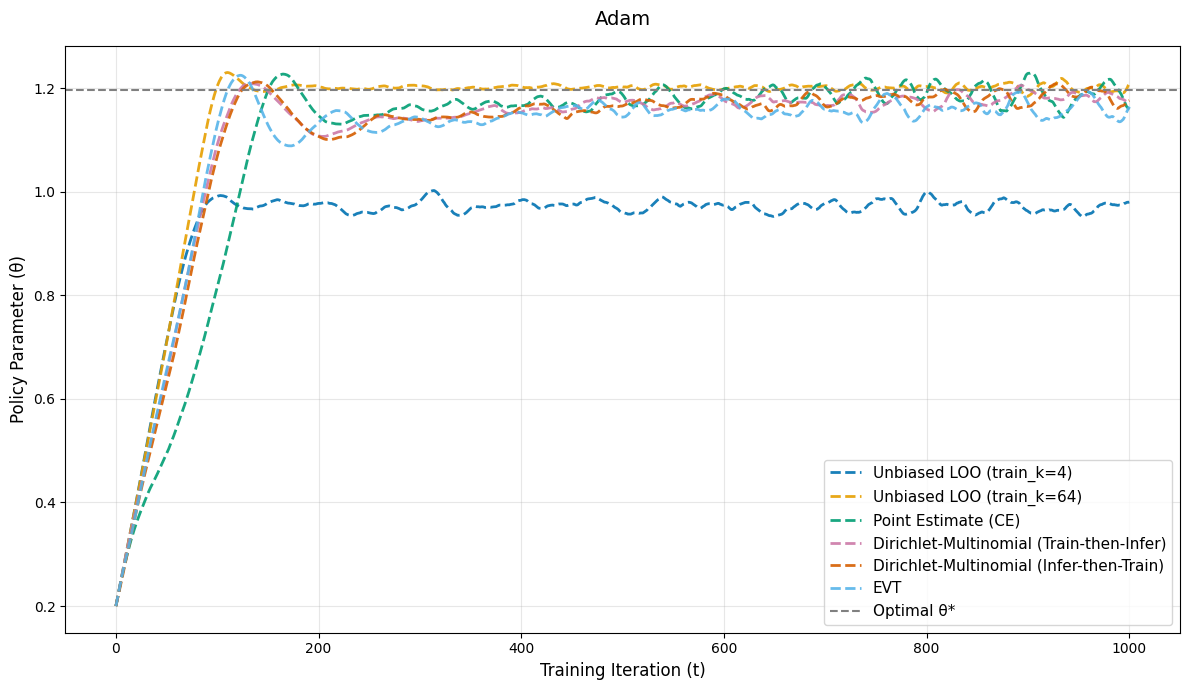

In [11]:
# =====================================================================
# 3. PLOT THE LEARNING CURVES
# =====================================================================
TRAJECTORY_SMOOTH_WINDOW = 25  # centered moving average; 1 = raw (match metrics cell)


# Okabe-Ito-style palette: colorblind-safe, spaced across hues (not the earlier `colors` from pass@k curves)
_line_colors = [
    "#0072B2",  # blue
    "#E69F00",  # orange
    "#009E73",  # bluish green
    "#CC79A7",  # red-purple
    "#D55E00",  # vermillion
    "#56B4E9",  # sky blue
    "#000000",  # black
    "#F0E442",  # yellow
    "#A65628",  # brown
]
plt.figure(figsize=(12, 7))

for idx, method in enumerate(thetas.keys()):
    plt.plot(trajectories[method], label=method, alpha=0.9, color=_line_colors[idx], linewidth=2, linestyle='--')

plt.title("Adam", fontsize=14, pad=15)
plt.xlabel("Training Iteration (t)", fontsize=12)
plt.ylabel("Policy Parameter (θ)", fontsize=12)
# plt.ylim(0.8, 1.5)
plt.axhline(k_to_best_theta[k], color='gray', linestyle='--', label='Optimal θ*')

plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

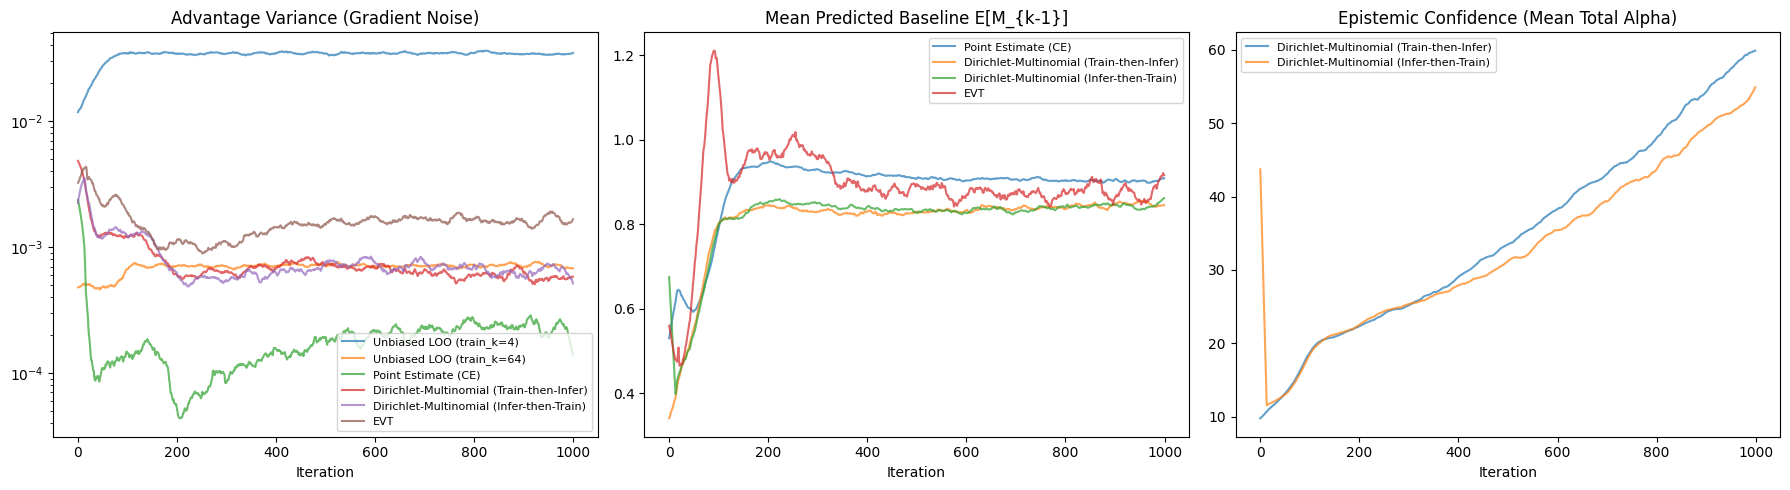


METRICS SUMMARY (Average of final 100 iterations)

--- Advantage Variance ---
  Unbiased LOO (train_k=4): 0.0341
  Unbiased LOO (train_k=64): 0.0007
  Point Estimate (CE): 0.0002
  Dirichlet-Multinomial (Train-then-Infer): 0.0006
  Dirichlet-Multinomial (Infer-then-Train): 0.0007
  EVT: 0.0016

--- Mean Baseline E[M_{k-1}] ---
  Point Estimate (CE): 0.9015
  Dirichlet-Multinomial (Train-then-Infer): 0.8488
  Dirichlet-Multinomial (Infer-then-Train): 0.8424
  EVT: 0.8770

--- Epistemic Confidence (Total Alpha_0) ---
  Dirichlet-Multinomial (Train-then-Infer): 57.4036
  Dirichlet-Multinomial (Infer-then-Train): 51.6525


In [12]:
# =====================================================================
# 5. VISUALIZE AND PRINT INTERNAL METRICS
# =====================================================================
METRIC_SMOOTH_WINDOW = 25  # centered moving average; use 1 for raw trajectories

def _smooth_1d(y, window):
    y = np.asarray(y, dtype=float)
    w = int(window)
    if w <= 1 or len(y) < 3:
        return y
    if w % 2 == 0:
        w += 1
    pad = w // 2
    ypad = np.pad(y, (pad, pad), mode="edge")
    kernel = np.ones(w, dtype=float) / w
    return np.convolve(ypad, kernel, mode="valid")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Advantage Variance
for m, vals in track_adv_var.items():
    axes[0].plot(_smooth_1d(vals, METRIC_SMOOTH_WINDOW), label=m, alpha=0.7)
axes[0].set_title("Advantage Variance (Gradient Noise)")
axes[0].set_yscale('log') # Log scale because CE variance explodes
axes[0].set_xlabel("Iteration")
axes[0].legend(fontsize=8)

# Plot 2: Mean Predicted Baseline (Exposes Data Leakage)
for m, vals in track_baseline_mean.items():
    axes[1].plot(_smooth_1d(vals, METRIC_SMOOTH_WINDOW), label=m, alpha=0.7)
axes[1].set_title("Mean Predicted Baseline E[M_{k-1}]")
axes[1].set_xlabel("Iteration")
axes[1].legend(fontsize=8)

# Plot 3: Epistemic Confidence (Alpha_0)
for m, vals in track_alpha0.items():
    axes[2].plot(_smooth_1d(vals, METRIC_SMOOTH_WINDOW), label=m, alpha=0.7)
axes[2].set_title("Epistemic Confidence (Mean Total Alpha)")
axes[2].set_xlabel("Iteration")
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig('variance.png')
plt.show()

# Print Summary for LLM Context
print("\n" + "="*60)
print("METRICS SUMMARY (Average of final 100 iterations)")
print("="*60)

print("\n--- Advantage Variance ---")
for m, vals in track_adv_var.items():
    print(f"  {m}: {np.mean(vals[-100:]):.4f}")
    
print("\n--- Mean Baseline E[M_{k-1}] ---")
for m, vals in track_baseline_mean.items():
    print(f"  {m}: {np.mean(vals[-100:]):.4f}")
    
print("\n--- Epistemic Confidence (Total Alpha_0) ---")
for m, vals in track_alpha0.items():
    print(f"  {m}: {np.mean(vals[-100:]):.4f}")
print("="*60)
